# 00 — Getting Started with Argo Float Data

This notebook walks you through:
1. Importing the packages we need
2. Downloading data for a single Argo float
3. Understanding what the data looks like
4. Making a simple temperature profile plot

---

If you haven't worked with jupyter notebooks before, they are sort of like a
textbook with code cells. You can run each cell by pressing `Shift+Enter` or
by clicking the play button in the top right corner. Often you'll see cells where plots are produced.
Plots can be saved by adding the line "plt.savefig('FILENAME.png')" under your plots. File outputs are saved in the same folder as the notebook.

---

## How to get float numbers

Each float is identified by a unique **WMO number**.  
We will use float **6902746** (located in the North Atlantic) throughout these notebooks.
You can find other floats at: https://fleetmonitoring.euro-argo.eu/

## Step 1 — Install packages (run once)

If you followed the setup instructions in the README you can **skip this cell**.  
Otherwise, uncomment and run the line below.

In [1]:
# Uncomment the line below only if you have NOT run the setup steps in the README
# !pip install argopy pandas matplotlib numpy xarray

## Step 2 — Import packages

We import all the tools we need here so they are available for the rest of the notebook.

In [2]:
import argopy                              # Argo data downloader
from argopy import DataFetcher as ArgoDataFetcher

import pandas as pd                        # Tables / DataFrames
import numpy as np                         # Numerical operations
import matplotlib.pyplot as plt            # Plotting

print('All packages imported successfully!')
print(f'argopy version: {argopy.__version__}')

All packages imported successfully!
argopy version: 1.4.0


## Step 3 — Download data for one float

We use `argopy` to download all available profiles for float **6902746**.  
The data comes from the Argo ERDDAP server, there are other severs out there, but this is the fastest.

> **Note:** The first download may take 30–60 seconds. Subsequent calls are cached.

In [3]:
# ---------------------------------------------------------------
# Choose your float — replace this WMO number to use a different float
# ---------------------------------------------------------------
WMO = 6903547

# Download data from the Argo ERDDAP server
print(f'Downloading data for float {WMO} ...')
loader = ArgoDataFetcher(src='erddap').float(WMO)

# argopy returns an xarray Dataset — we convert it to a pandas DataFrame
# which is easier to work with if you are new to Python
ds  = loader.to_xarray()       # xarray Dataset
df  = ds.to_dataframe().reset_index()   # pandas DataFrame

print(f'Download complete!  {len(df):,} data points retrieved.')

Download complete!  46,425 data points retrieved.


## Step 4 — Explore the data

A **DataFrame** is like a spreadsheet.  Each row is one measurement, and each column is one variable.

In [4]:
# Show the first 5 rows
df.head()

,N_POINTS,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
0,0,1,D,D,6903547,1,10.900000,2.4,1,35.052101,0.01,1,6.000,0.002,1,1,71.086,5.997,2018-05-31 12:23:00
1,1,1,D,D,6903547,1,12.200000,2.4,1,35.052101,0.01,1,6.000,0.002,1,1,71.086,5.997,2018-05-31 12:23:00
2,2,1,D,D,6903547,1,14.000000,2.4,1,35.052101,0.01,1,5.998,0.002,1,1,71.086,5.997,2018-05-31 12:23:00
3,3,1,D,D,6903547,1,16.000000,2.4,1,35.052101,0.01,1,5.999,0.002,1,1,71.086,5.997,2018-05-31 12:23:00
4,4,1,D,D,6903547,1,18.200001,2.4,1,35.052101,0.01,1,5.999,0.002,1,1,71.086,5.997,2018-05-31 12:23:00


In [5]:
# Show all column names
print('Columns in the dataset:')
print(df.columns.tolist())

Columns in the dataset:
['N_POINTS', np.str_('CYCLE_NUMBER'), np.str_('DATA_MODE'), np.str_('DIRECTION'), np.str_('PLATFORM_NUMBER'), np.str_('POSITION_QC'), np.str_('PRES'), np.str_('PRES_ERROR'), np.str_('PRES_QC'), np.str_('PSAL'), np.str_('PSAL_ERROR'), np.str_('PSAL_QC'), np.str_('TEMP'), np.str_('TEMP_ERROR'), np.str_('TEMP_QC'), np.str_('TIME_QC'), 'LATITUDE', 'LONGITUDE', 'TIME']


In [6]:
# Summary statistics for the main oceanographic variables
df[['PRES', 'TEMP', 'PSAL']].describe().round(2)

,PRES,TEMP,PSAL
count,46425.00,46425.00,46425.00
mean,739.14,2.14,34.97
std,611.67,2.82,0.07
min,2.10,-0.77,34.69
25%,205.70,-0.40,34.91
50%,507.90,0.76,34.92
75%,1257.60,5.03,35.04
max,2036.40,10.77,35.13


In [7]:
# How many profiles (cycles) are in the dataset?
n_cycles = df['CYCLE_NUMBER'].nunique()
print(f'Number of profiles (cycles): {n_cycles}')
print(f'Date range: {df["TIME"].min().date()}  to  {df["TIME"].max().date()}')

Number of profiles (cycles): 77
Date range: 2018-05-31  to  2020-07-01


### Key variables explained

| Column | Meaning | Unit |
|---|---|---|
| `PRES` | Pressure (≈ depth) | dbar (1 dbar ≈ 1 m) |
| `TEMP` | In-situ temperature | °C |
| `PSAL` | Practical salinity | PSU (dimensionless) |
| `TIME` | Date and time of the profile | UTC |
| `CYCLE_NUMBER` | Profile counter for this float | — |
| `LATITUDE` | Float latitude | degrees North |
| `LONGITUDE` | Float longitude | degrees East |

## Step 5 — Plot a single temperature profile

Let's pick one cycle and plot temperature vs depth.

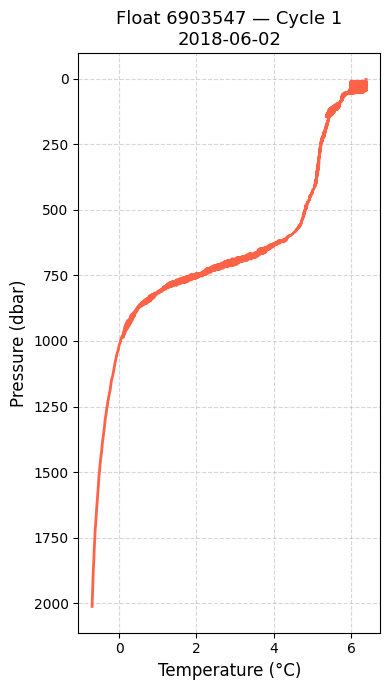

In [8]:
# Select the first profile (cycle 1)
cycle_to_plot = 1
profile = df[df['CYCLE_NUMBER'] == cycle_to_plot].sort_values('PRES')

# --- Plot ---
fig, ax = plt.subplots(figsize=(4, 7))

ax.plot(profile['TEMP'], profile['PRES'], color='tomato', linewidth=2)

# Invert y-axis so surface (0 dbar) is at the top
ax.invert_yaxis()

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Pressure (dbar)', fontsize=12)
ax.set_title(f'Float {WMO} — Cycle {cycle_to_plot}\n{profile["TIME"].iloc[0].date()}',
             fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Step 6 — Plot several profiles together

Plotting multiple cycles on the same axes lets us see seasonal variability.

C:\Users\natal\AppData\Local\Temp\ipykernel_33700\2434560165.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


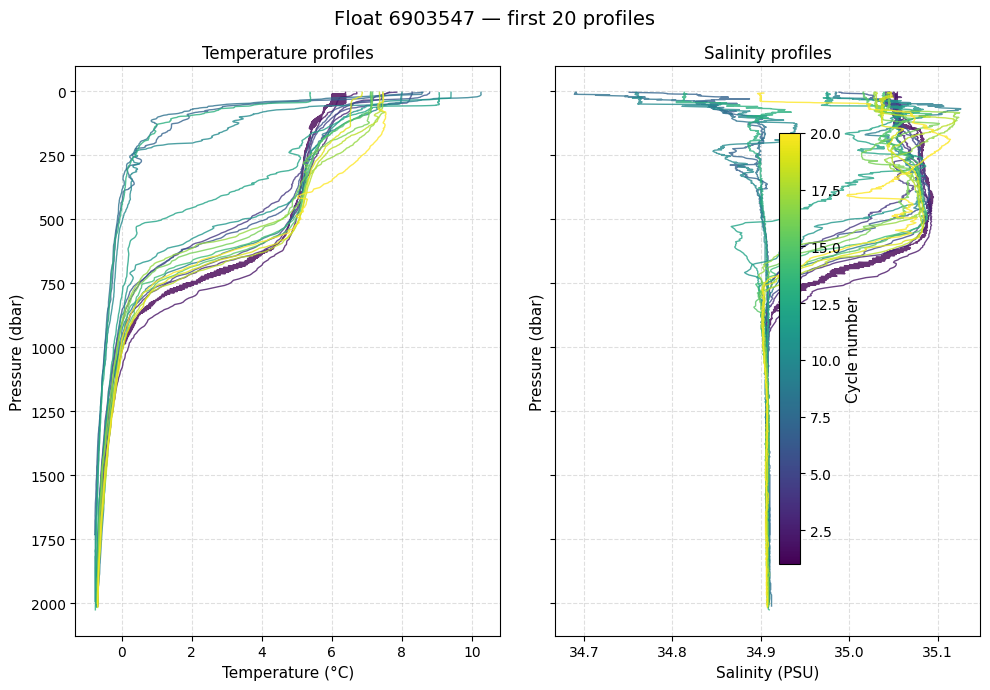

In [9]:
# Plot the first 20 cycles, coloured by cycle number
cycles_to_plot = sorted(df['CYCLE_NUMBER'].unique())[:20]

fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True)

# Use a colourmap so each cycle gets a distinct colour
colours = plt.cm.viridis(np.linspace(0, 1, len(cycles_to_plot)))

for colour, cycle in zip(colours, cycles_to_plot):
    profile = df[df['CYCLE_NUMBER'] == cycle].sort_values('PRES')
    axes[0].plot(profile['TEMP'], profile['PRES'], color=colour, alpha=0.8, linewidth=1)
    axes[1].plot(profile['PSAL'], profile['PRES'], color=colour, alpha=0.8, linewidth=1)

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylabel('Pressure (dbar)', fontsize=11)

axes[0].invert_yaxis()
axes[0].set_xlabel('Temperature (°C)', fontsize=11)
axes[0].set_title('Temperature profiles', fontsize=12)
axes[1].set_xlabel('Salinity (PSU)', fontsize=11)
axes[1].set_title('Salinity profiles', fontsize=12)

# Add a colourbar to show which cycle is which
sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=cycles_to_plot[0], vmax=cycles_to_plot[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.8)
cbar.set_label('Cycle number', fontsize=11)

fig.suptitle(f'Float {WMO} — first {len(cycles_to_plot)} profiles', fontsize=14)
plt.tight_layout()
plt.show()

## Step 7 - Plotting a float's trajectory

Let's plot where the float has been in the world, Note, if you want to be more advanced in the future, look at plotting borders long with the floats position, AI or [GeoPandas](https://geopandas.org/en/stable/index.html) is a great place to start but will need installation of some additional python packages.

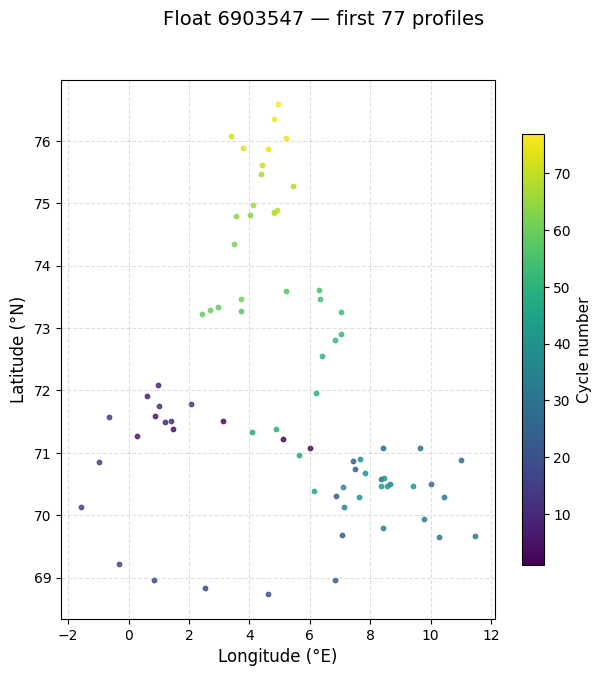

In [10]:
plt.show()
# Start by creating a figure
fig, ax = plt.subplots(figsize=(7, 7))

# make sure we have sorted everything by time
df = df.sort_values("TIME")

# get the lat and lons of each measurment, but only save the first one! otherwise we'll get a lot of points for each row in our dataframe
df_cycles = df.groupby("CYCLE_NUMBER")[["LATITUDE", "LONGITUDE"]].first().reset_index()
latitudes = df_cycles["LATITUDE"]
longitudes = df_cycles["LONGITUDE"]

# and get the cycle numbers
cycle_numbers = df_cycles["CYCLE_NUMBER"]
# Create a color map for each cycle
cycles_to_plot = cycle_numbers.unique()
norm = plt.Normalize(vmin=cycle_numbers.min(), vmax=cycle_numbers.max())
colours = plt.cm.viridis(norm(cycle_numbers))

# Plot each point
for color, lat, lon in zip(colours, latitudes, longitudes):
    ax.scatter(lon, lat, color=color, s=10, alpha=0.8)

# Add a colourbar to show which cycle is which
sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(vmin=cycle_numbers.min(), vmax=cycle_numbers.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Cycle number', fontsize=11)

fig.suptitle(f'Float {WMO} — first {len(cycles_to_plot)} profiles', fontsize=14)
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

---

## Summary

You have learned how to:
- Download Argo float data with `argopy`
- Convert the data to a pandas DataFrame
- Inspect the data columns and statistics
- Plot individual and multiple temperature/salinity profiles

**Next notebook:** `01_single_float_contours.ipynb` — visualise how the whole water column
evolves over time using colour-filled contour plots.